# External Data Preparation

Member C deliverable, covering ABS and demographic data used as external
features for the Victorian rental price model.

## Geography version

This project uses ASGS Edition 3 SA2 boundaries, released July 2021.
Edition 4 became available from July 2026 but was not used, because the
population projection and income datasets are compiled against 2021 SA2
codes. Mixing editions would cause silent join failures where a property
maps to a 2026 SA2 that has no matching 2021 demographic record.

## Known data characteristics

Victoria contains 524 SA2 regions. Two of these are special purpose codes
with no geographic area, `Migratory - Offshore - Shipping (Vic.)` and
`No usual address (Vic.)`. These will have no demographic data attached
and no properties will fall within them. They are retained in the
boundary file for completeness but excluded from analysis.

## Source data

| Dataset | Source | Reference period |
|---|---|---|
| SA2 digital boundaries | ABS ASGS Edition 3 | 2021, GDA2020 |
| Dataset | Source | Reference period |
|---|---|---|
| SA2 digital boundaries | ABS ASGS Edition 3 | 2021, GDA2020 |
| Population, household and dwelling projections | VIF2023 Second Release | 2021 to 2036, four year points |

In [1]:
import io
import os
import sys
import zipfile

os.environ.setdefault("PROJ_LIB", os.path.join(sys.prefix, "share", "proj"))
os.environ.setdefault("GDAL_DATA", os.path.join(sys.prefix, "share", "gdal"))

from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# All paths are relative to the project root, one level above notebooks
PROJECT_ROOT = Path.cwd().parent
LANDING_DIR = PROJECT_ROOT / "data" / "landing"
RAW_DIR = PROJECT_ROOT / "data" / "raw"
CURATED_DIR = PROJECT_ROOT / "data" / "curated"

SA2_SHAPEFILE = (
    LANDING_DIR / "abs" / "SA2_2021_AUST_SHP_GDA2020" / "SA2_2021_AUST_GDA2020.shp"
)

assert SA2_SHAPEFILE.exists(), f"Shapefile not found at {SA2_SHAPEFILE}"
print(f"Project root: {PROJECT_ROOT}")
print(f"Shapefile found: {SA2_SHAPEFILE.name}")

Project root: /Users/all_for_alin/Downloads/26-s2-ADS/project2
Shapefile found: SA2_2021_AUST_GDA2020.shp


In [2]:
sa2_all = gpd.read_file(SA2_SHAPEFILE, engine="pyogrio")

print(f"Rows: {len(sa2_all):,}")
print(f"CRS: {sa2_all.crs}")
print(f"\nColumns:\n{list(sa2_all.columns)}")
sa2_all.head(3)

Rows: 2,473
CRS: EPSG:7844

Columns:
['SA2_CODE21', 'SA2_NAME21', 'CHG_FLAG21', 'CHG_LBL21', 'SA3_CODE21', 'SA3_NAME21', 'SA4_CODE21', 'SA4_NAME21', 'GCC_CODE21', 'GCC_NAME21', 'STE_CODE21', 'STE_NAME21', 'AUS_CODE21', 'AUS_NAME21', 'AREASQKM21', 'LOCI_URI21', 'geometry']


,SA2_CODE21,SA2_NAME21,CHG_FLAG21,CHG_LBL21,SA3_CODE21,SA3_NAME21,SA4_CODE21,SA4_NAME21,GCC_CODE21,GCC_NAME21,STE_CODE21,STE_NAME21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,geometry
0,101021007,Braidwood,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,3418.3525,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.58424 -35.44426, 149.58444 -35.4..."
1,101021008,Karabar,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,6.9825,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.21899 -35.36738, 149.218 -35.366..."
2,101021009,Queanbeyan,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,4.7620,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.21326 -35.34325, 149.21619 -35.3..."


In [3]:
# Inspect the state name column before filtering, since ABS column naming
# uses a two digit year suffix that can differ between products.
print(sa2_all["STE_NAME21"].value_counts())

STE_NAME21
New South Wales                 644
Queensland                      548
Victoria                        524
Western Australia               267
South Australia                 176
Australian Capital Territory    136
Tasmania                        101
Northern Territory               70
Other Territories                 6
Outside Australia                 1
Name: count, dtype: int64


In [4]:
sa2_vic = sa2_all[sa2_all["STE_NAME21"] == "Victoria"].copy()

# The ABS record count table for ASGS Edition 3 states Victoria has 524 SA2s.
assert len(sa2_vic) == 524, f"Expected 524 Victorian SA2s, got {len(sa2_vic)}"

# SA2 codes must stay as zero padded nine character strings. Reading them as
# integers silently drops leading zeros and breaks every downstream join.
sa2_vic["SA2_CODE21"] = sa2_vic["SA2_CODE21"].astype(str).str.zfill(9)
assert sa2_vic["SA2_CODE21"].str.len().eq(9).all(), "SA2 codes must be 9 characters"
assert sa2_vic["SA2_CODE21"].is_unique, "SA2 codes must be unique"

print(f"Victorian SA2s: {len(sa2_vic)}")
print(f"CRS: {sa2_vic.crs}")
sa2_vic[["SA2_CODE21", "SA2_NAME21", "SA3_NAME21", "GCC_NAME21"]].head()

Victorian SA2s: 524
CRS: EPSG:7844


,SA2_CODE21,SA2_NAME21,SA3_NAME21,GCC_NAME21
644,201011001,Alfredton,Ballarat,Rest of Vic.
645,201011002,Ballarat,Ballarat,Rest of Vic.
646,201011005,Buninyong,Ballarat,Rest of Vic.
647,201011006,Delacombe,Ballarat,Rest of Vic.
648,201011007,Smythes Creek,Ballarat,Rest of Vic.


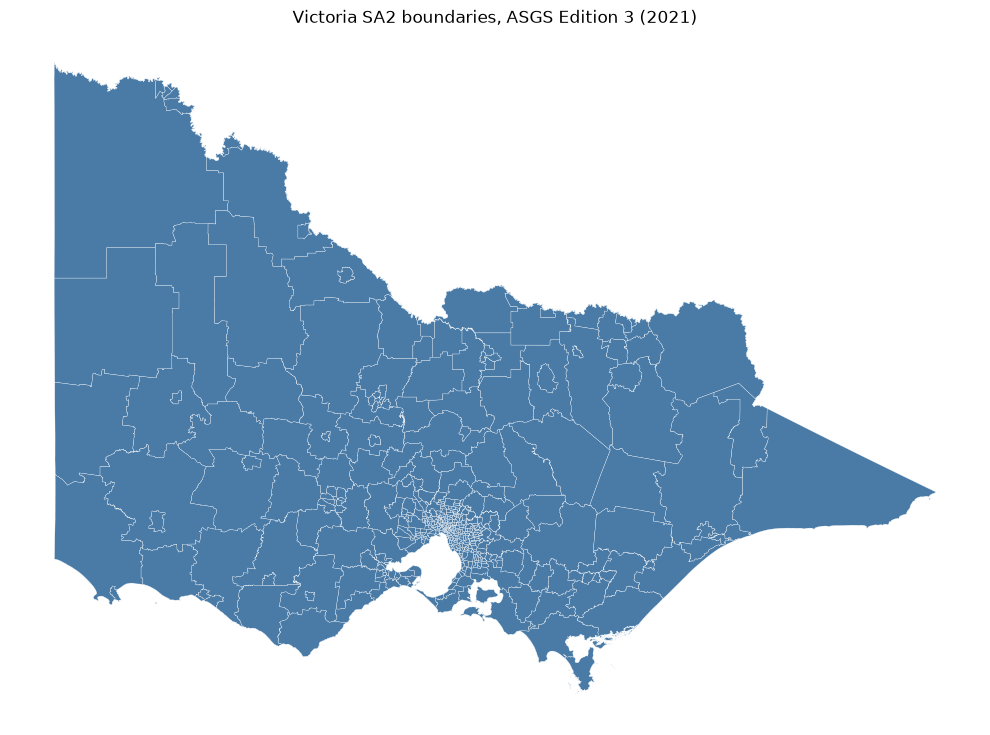

In [5]:
fig, ax = plt.subplots(figsize=(10, 9))
sa2_vic.plot(ax=ax, edgecolor="white", linewidth=0.2, color="#4a7ba7")
ax.set_title("Victoria SA2 boundaries, ASGS Edition 3 (2021)")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "plots" / "sa2_vic_boundaries.png", dpi=150)
plt.show()

In [6]:
# Zero SA2s are designed to have no population. They have geometry but will
# have no matching demographic data later, which is expected, not a bug.
special = sa2_vic[sa2_vic["SA2_NAME21"].str.contains(
    "No usual address|Migratory|Offshore|Shipping", case=False, na=False
)]
print(f"Special purpose SA2s: {len(special)}")
print(special[["SA2_CODE21", "SA2_NAME21", "AREASQKM21"]].to_string(index=False))

# Flag them now so the join diagnostics later do not look alarming
sa2_vic["is_special_purpose"] = sa2_vic["SA2_CODE21"].isin(special["SA2_CODE21"])
print(f"\nAnalysable SA2s: {(~sa2_vic['is_special_purpose']).sum()}")

Special purpose SA2s: 2
SA2_CODE21                             SA2_NAME21  AREASQKM21
 297979799 Migratory - Offshore - Shipping (Vic.)         NaN
 299999499                No usual address (Vic.)         NaN

Analysable SA2s: 522


In [7]:
RAW_DIR.mkdir(parents=True, exist_ok=True)
output_path = RAW_DIR / "sa2_vic_boundaries.gpkg"

sa2_vic.to_file(output_path, driver="GPKG", engine="pyogrio")

# Verify the round trip, since a file that writes without error can still
# fail to read back correctly.
check = gpd.read_file(output_path, engine="pyogrio")
assert len(check) == 524, f"Round trip failed, got {len(check)} rows"
assert check.crs == sa2_vic.crs, "CRS was not preserved on write"
assert check["SA2_CODE21"].str.len().eq(9).all(), "SA2 code padding lost on write"

print(f"Wrote {len(check)} Victorian SA2s to {output_path.name}")
print(f"CRS preserved: {check.crs}")

Wrote 524 Victorian SA2s to sa2_vic_boundaries.gpkg
CRS preserved: EPSG:7844


In [8]:
VIF_FILE = (
    LANDING_DIR / "vif" / "VIF2023_SA2_Pop_Hhold_Dwelling_Projections_to_2036_Release_2.xlsx"
)
assert VIF_FILE.exists(), f"VIF file not found at {VIF_FILE}"

# The VIF sheets carry six rows of title and contact information, a blank row,
# then the real header on row 10 and a further blank row before the data.
VIF_HEADER_ROW = 9  # zero indexed, so this is spreadsheet row 10
VIF_CODE_COL = "SA2  code"  # note the double space in the source file
PROJECTION_YEARS = [2021, 2026, 2031, 2036]


def read_vif_sheet(path, sheet_name, value_prefix):
    """
    Read one VIF projection sheet and return SA2 level rows only.

    The SA2 code arrives as a float, so it is converted through int before
    string conversion. Converting the float directly to string would yield
    values such as 201011001.0 which can never match the ABS boundary codes,
    and the resulting join would fail silently rather than raise.
    """
    df = pd.read_excel(path, sheet_name=sheet_name, header=VIF_HEADER_ROW)
    df = df.dropna(subset=["Region Type"])

    # The file stacks SA2, SA3, SA4, GCCSA and State rows in one sheet.
    # Keeping any of the higher levels would double count population.
    df = df[df["Region Type"] == "SA2"].copy()

    df["sa2_code_2021"] = (
        df[VIF_CODE_COL].astype("int64").astype(str).str.zfill(9)
    )
    df = df.rename(columns={"Region": "sa2_name_vif"})

    keep = ["sa2_code_2021", "sa2_name_vif"] + PROJECTION_YEARS
    df = df[keep].rename(
        columns={year: f"{value_prefix}_{year}" for year in PROJECTION_YEARS}
    )

    assert df["sa2_code_2021"].is_unique, f"Duplicate SA2 codes in {sheet_name}"
    assert df["sa2_code_2021"].str.len().eq(9).all(), "SA2 code must be 9 characters"
    return df.reset_index(drop=True)


print("Function defined.")

Function defined.


In [9]:
population = read_vif_sheet(VIF_FILE, "Total_Population", "population")
dwellings = read_vif_sheet(VIF_FILE, "Total_Dwellings", "dwellings")
households = read_vif_sheet(VIF_FILE, "Total_Households", "households")

for name, frame in [
    ("population", population),
    ("dwellings", dwellings),
    ("households", households),
]:
    print(f"{name}: {len(frame)} SA2 rows")

# VIF covers the 522 analysable Victorian SA2s, excluding the two special
# purpose codes that have no geographic area.
assert len(population) == 522, f"Expected 522 SA2 rows, got {len(population)}"

population.head()

population: 522 SA2 rows
dwellings: 522 SA2 rows
households: 522 SA2 rows


,sa2_code_2021,sa2_name_vif,population_2021,population_2026,population_2031,population_2036
0,201011001,Alfredton,16841.0,20756.256163,23604.443836,26060.320807
1,201011002,Ballarat,12071.0,11698.293593,11803.430603,11985.992387
2,201011005,Buninyong,7229.0,7372.079773,7685.113372,8028.887243
3,201011006,Delacombe,10648.0,15915.186041,20475.587469,24965.202439
4,201011007,Smythes Creek,4211.0,4312.098530,4457.413406,4725.467837


In [10]:
vif = (
    population
    .merge(dwellings.drop(columns=["sa2_name_vif"]), on="sa2_code_2021", how="outer", indicator="_m1")
    .merge(households.drop(columns=["sa2_name_vif"]), on="sa2_code_2021", how="outer", indicator="_m2")
)

# An outer join with indicators exposes any SA2 present in one sheet but not
# another. Both indicators must be "both" for every row.
assert (vif["_m1"] == "both").all(), "Population and dwellings sheets disagree"
assert (vif["_m2"] == "both").all(), "Households sheet disagrees with the others"
vif = vif.drop(columns=["_m1", "_m2"])

assert len(vif) == 522, f"Merge changed row count to {len(vif)}"
print(f"Merged VIF table: {len(vif)} rows, {len(vif.columns)} columns")
print(list(vif.columns))

Merged VIF table: 522 rows, 14 columns
['sa2_code_2021', 'sa2_name_vif', 'population_2021', 'population_2026', 'population_2031', 'population_2036', 'dwellings_2021', 'dwellings_2026', 'dwellings_2031', 'dwellings_2036', 'households_2021', 'households_2026', 'households_2031', 'households_2036']


### First pass at the derived features

The summary below reveals two problems. The row counts fall short of 522 and
several columns report infinite maxima, both of which point to division by
zero. The warnings raised here are expected and are diagnosed in the cells
that follow.

In [11]:
vif_features = vif.copy()

# Growth rates are stored as proportions, not percentages, so a value of
# 0.15 means fifteen percent growth over the stated window.
vif_features["population_growth_5y"] = (
    vif_features["population_2031"] / vif_features["population_2026"] - 1
)
vif_features["population_growth_10y"] = (
    vif_features["population_2036"] / vif_features["population_2026"] - 1
)
vif_features["household_growth_10y"] = (
    vif_features["households_2036"] / vif_features["households_2026"] - 1
)
vif_features["dwelling_growth_10y"] = (
    vif_features["dwellings_2036"] / vif_features["dwellings_2026"] - 1
)

# Rental pressure. Households represent demand for somewhere to live and
# dwellings represent the supply of places to live. Where household growth
# outpaces dwelling growth, competition for each available property rises,
# which is a more direct driver of rent than headcount growth alone.
vif_features["demand_supply_gap_10y"] = (
    vif_features["household_growth_10y"] - vif_features["dwelling_growth_10y"]
)

# Occupancy ratio. Values close to one indicate most dwellings are occupied,
# lower values indicate vacancy, holiday homes or unoccupied stock.
vif_features["occupancy_ratio_2026"] = (
    vif_features["households_2026"] / vif_features["dwellings_2026"]
)
vif_features["avg_household_size_2026"] = (
    vif_features["population_2026"] / vif_features["households_2026"]
)

new_cols = [
    "population_growth_5y",
    "population_growth_10y",
    "household_growth_10y",
    "dwelling_growth_10y",
    "demand_supply_gap_10y",
    "occupancy_ratio_2026",
    "avg_household_size_2026",
]
vif_features[new_cols].describe().round(4)

/opt/anaconda3/envs/mast30034_p2/lib/python3.11/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/opt/anaconda3/envs/mast30034_p2/lib/python3.11/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/opt/anaconda3/envs/mast30034_p2/lib/python3.11/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/opt/anaconda3/envs/mast30034_p2/lib/python3.11/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/opt/anaconda3/envs/mast30034_p2/lib/python3.11/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,population_growth_5y,population_growth_10y,household_growth_10y,dwelling_growth_10y,demand_supply_gap_10y,occupancy_ratio_2026,avg_household_size_2026
count,519.0000,519.0000,512.0000,519.0000,511.0000,518.0000,518.0000
mean,inf,inf,inf,inf,-0.0007,0.9095,inf
std,NaN,NaN,NaN,NaN,0.0063,0.1289,NaN
min,-0.0911,-0.1268,-0.0104,0.0000,-0.0267,0.0000,1.6418
25%,0.0209,0.0414,0.0651,0.0644,0.0000,0.9100,2.2764
50%,0.0429,0.0868,0.1084,0.1059,0.0000,0.9400,2.5291
75%,0.0831,0.1643,0.1808,0.1789,0.0000,0.9637,2.8198
max,inf,inf,inf,inf,0.0465,0.9900,inf


### Diagnosing infinite values in the derived ratios

The first attempt at computing growth ratios produced infinite values and a
row count below 522, indicating division by zero. The cell below identifies
which SA2s are affected before any decision is made about how to handle them.

In [12]:
import numpy as np

# Identify SA2s with zero denominators, which produce inf or NaN above
zero_pop = vif_features["population_2026"] == 0
zero_hh = vif_features["households_2026"] == 0
zero_dw = vif_features["dwellings_2026"] == 0

print(f"SA2s with zero 2026 population: {zero_pop.sum()}")
print(f"SA2s with zero 2026 households: {zero_hh.sum()}")
print(f"SA2s with zero 2026 dwellings:  {zero_dw.sum()}")

problem = vif_features[zero_pop | zero_hh | zero_dw]
print(f"\nTotal affected SA2s: {len(problem)}")
print(
    problem[[
        "sa2_code_2021", "sa2_name_vif",
        "population_2026", "households_2026", "dwellings_2026",
    ]].to_string(index=False)
)

SA2s with zero 2026 population: 4
SA2s with zero 2026 households: 11
SA2s with zero 2026 dwellings:  4

Total affected SA2s: 11
sa2_code_2021                   sa2_name_vif  population_2026  households_2026  dwellings_2026
    205021080                    Alps - East         0.000000              0.0        0.000000
    205021083                      Lake King         0.000000              0.0        0.000000
    205031088                  French Island       109.988102              0.0      134.000000
    205031092             Wilsons Promontory        15.000000              0.0        2.855198
    205051099                    Alps - West        23.000000              0.0       11.214106
    206041127    West Melbourne - Industrial         0.000000              0.0        0.000000
    206041507 Royal Botanic Gardens Victoria         0.000000              0.0        0.000000
    208031184                       Braeside        28.000000              0.0       23.000000
    208031192    

In [13]:
import numpy as np

# Eleven Victorian SA2s are non residential land such as airports, national
# parks, industrial estates and water bodies. VIF records zero households for
# them, so any household based ratio divides by zero. These areas contain no
# rental market and are flagged for exclusion rather than imputed, since an
# imputed value would imply a housing market that does not exist.
vif_features["is_residential"] = (
    (vif_features["population_2026"] > 0)
    & (vif_features["households_2026"] > 0)
    & (vif_features["dwellings_2026"] > 0)
)

n_excluded = (~vif_features["is_residential"]).sum()
assert n_excluded == 11, f"Expected 11 non residential SA2s, got {n_excluded}"

# Replace the infinities produced by the zero denominators with NaN so that
# downstream tools raise or skip rather than silently propagate inf.
ratio_cols = [
    "population_growth_5y",
    "population_growth_10y",
    "household_growth_10y",
    "dwelling_growth_10y",
    "demand_supply_gap_10y",
    "occupancy_ratio_2026",
    "avg_household_size_2026",
]
vif_features[ratio_cols] = vif_features[ratio_cols].replace([np.inf, -np.inf], np.nan)

residential = vif_features[vif_features["is_residential"]]
print(f"Residential SA2s: {len(residential)}")
print(f"Non residential SA2s excluded: {n_excluded}")
assert residential[ratio_cols].notna().all().all(), \
    "Nulls remain in derived features for residential SA2s"

residential[ratio_cols].describe().round(4)

Residential SA2s: 511
Non residential SA2s excluded: 11


,population_growth_5y,population_growth_10y,household_growth_10y,dwelling_growth_10y,demand_supply_gap_10y,occupancy_ratio_2026,avg_household_size_2026
count,511.0000,511.0000,511.0000,511.0000,511.0000,511.0000,511.0000
mean,0.0733,0.1466,0.1682,0.1689,-0.0007,0.9219,2.5537
std,0.1265,0.2383,0.2337,0.2337,0.0063,0.0730,0.3862
min,-0.0430,-0.0868,-0.0104,0.0146,-0.0267,0.4200,1.6418
25%,0.0220,0.0426,0.0650,0.0651,0.0000,0.9100,2.2722
50%,0.0433,0.0875,0.1081,0.1067,0.0000,0.9400,2.5253
75%,0.0834,0.1663,0.1799,0.1794,0.0000,0.9650,2.7974
max,1.9324,3.3178,2.9586,2.9586,0.0465,0.9900,3.7989


All eleven affected SA2s are non residential land: four airports, three
national park areas, two industrial estates, and two water or island areas.
VIF records zero households for each, so household based ratios are
undefined. These areas contain no rental market, so they are flagged and
excluded rather than imputed. Imputing a value would imply a housing market
that does not exist.

In [14]:
print("Fastest growing residential SA2s, 2026 to 2036")
print(
    residential
    .nlargest(10, "population_growth_10y")[
        ["sa2_name_vif", "population_2026", "population_2036", "population_growth_10y"]
    ]
    .round(3)
    .to_string(index=False)
)

print("\nHighest demand supply gap, 2026 to 2036")
print(
    residential
    .nlargest(10, "demand_supply_gap_10y")[
        ["sa2_name_vif", "household_growth_10y", "dwelling_growth_10y", "demand_supply_gap_10y"]
    ]
    .round(4)
    .to_string(index=False)
)

Fastest growing residential SA2s, 2026 to 2036
             sa2_name_vif  population_2026  population_2036  population_growth_10y
    Flemington Racecourse          528.047         2280.022                  3.318
Port Melbourne Industrial        12185.950        35881.153                  1.944
                   Wallan        37126.000        87876.000                  1.367
Rockbank - Mount Cottrell        41470.660        85990.069                  1.074
               Whittlesea        22798.760        45662.048                  1.003
      Clyde North - South        31590.448        63246.660                  1.002
   Fraser Rise - Plumpton        26194.794        52294.466                  0.996
          Tarneit - North        19695.316        38694.690                  0.965
     Wyndham Vale - North        16850.904        33090.369                  0.964
         Cranbourne South        32310.303        62795.254                  0.944

Highest demand supply gap, 2026 to 2036

In [15]:
# Percentage growth is unstable when the base population is small. A racecourse
# with 528 residents shows a 332 percent increase from a few hundred extra
# people, which is arithmetically correct but meaningless as a rental market
# signal. A floor of 1000 residents in 2026 removes these cases while keeping
# every genuine residential area.
MIN_POPULATION_2026 = 1000

vif_features["is_analysable"] = (
    vif_features["is_residential"]
    & (vif_features["population_2026"] >= MIN_POPULATION_2026)
)

analysable = vif_features[vif_features["is_analysable"]]
print(f"Analysable SA2s: {len(analysable)}")
print(f"Dropped for small base: {vif_features['is_residential'].sum() - len(analysable)}")

print("\nFastest growing SA2s with a population base above 1000")
print(
    analysable
    .nlargest(10, "population_growth_10y")[
        ["sa2_name_vif", "population_2026", "population_2036", "population_growth_10y"]
    ]
    .round(3)
    .to_string(index=False)
)

Analysable SA2s: 509
Dropped for small base: 2

Fastest growing SA2s with a population base above 1000
             sa2_name_vif  population_2026  population_2036  population_growth_10y
Port Melbourne Industrial        12185.950        35881.153                  1.944
                   Wallan        37126.000        87876.000                  1.367
Rockbank - Mount Cottrell        41470.660        85990.069                  1.074
               Whittlesea        22798.760        45662.048                  1.003
      Clyde North - South        31590.448        63246.660                  1.002
   Fraser Rise - Plumpton        26194.794        52294.466                  0.996
          Tarneit - North        19695.316        38694.690                  0.965
     Wyndham Vale - North        16850.904        33090.369                  0.964
         Cranbourne South        32310.303        62795.254                  0.944
Cobblebank - Strathtulloh        14033.547        26633.402        

Note: pyarrow was replaced with fastparquet as the parquet engine. On
osx-arm64, pyarrow failed to load due to a libprotobuf symbol mismatch in
its liborc dependency. fastparquet has no such native dependency chain.

In [16]:
CURATED_DIR.mkdir(parents=True, exist_ok=True)

vif_output = vif_features[[
    "sa2_code_2021",
    "sa2_name_vif",
    "population_2021", "population_2026", "population_2031", "population_2036",
    "households_2026", "households_2036",
    "dwellings_2026", "dwellings_2036",
    "population_growth_5y", "population_growth_10y",
    "household_growth_10y", "dwelling_growth_10y",
    "demand_supply_gap_10y",
    "occupancy_ratio_2026", "avg_household_size_2026",
    "is_residential", "is_analysable",
]].copy()

output_path = RAW_DIR / "vif_sa2_projections.parquet"
vif_output.to_parquet(output_path, index=False)

# Round trip check. Parquet preserves dtypes, but the string padding on the
# SA2 code is the one thing that must survive for every later join to work.
check = pd.read_parquet(output_path)
assert len(check) == 522, f"Round trip failed, got {len(check)} rows"
assert check["sa2_code_2021"].dtype == object, "SA2 code must remain a string"
assert check["sa2_code_2021"].str.len().eq(9).all(), "SA2 code padding lost"
assert check["is_analysable"].sum() == 509, "Analysable flag did not survive"

print(f"Wrote {len(check)} rows to {output_path.name}")
print(f"Residential: {check['is_residential'].sum()}, analysable: {check['is_analysable'].sum()}")

Wrote 522 rows to vif_sa2_projections.parquet
Residential: 511, analysable: 509


In [17]:
INCOME_FILE = LANDING_DIR / "income" / "abs_total_income_sa2_2018_19_to_2022_23.xlsx"
assert INCOME_FILE.exists(), f"Income file not found at {INCOME_FILE}"

INCOME_YEARS = ["2018-19", "2019-20", "2020-21", "2021-22", "2022-23"]
# The sheet uses a two level header. Row 6 names the metric and row 7 names
# the financial year, so the metric blocks are read by position instead.
INCOME_BLOCKS = {
    "earners": 2,
    "median_age": 7,
    "income_sum": 12,
    "income_median": 17,
    "income_mean": 22,
}

raw_income = pd.read_excel(
    INCOME_FILE, sheet_name="Table 1.4", header=None, skiprows=9
)

# Column 0 holds the SA2 code for area rows but holds names such as
# "Australia" or "New South Wales" for the aggregate rows that precede them,
# and the footnote rows at the bottom. Keeping only nine digit numeric codes
# removes both without hard coding row positions.
code_col = raw_income[0].astype(str).str.strip()
is_sa2_row = code_col.str.fullmatch(r"\d{9}")
raw_income = raw_income[is_sa2_row].copy()

income = pd.DataFrame({
    "sa2_code_2021": code_col[is_sa2_row],
    "sa2_name_income": raw_income[1],
})

for metric, start in INCOME_BLOCKS.items():
    for offset, year in enumerate(INCOME_YEARS):
        # "np" marks values withheld to protect confidentiality. Coercing to
        # numeric turns them into NaN so they propagate as missing rather
        # than forcing the whole column to object dtype.
        income[f"{metric}_{year}"] = pd.to_numeric(
            raw_income[start + offset], errors="coerce"
        )

income = income.reset_index(drop=True)
assert income["sa2_code_2021"].is_unique, "Duplicate SA2 codes in income table"
assert income["sa2_code_2021"].str.len().eq(9).all(), "SA2 code must be 9 characters"

print(f"National SA2 rows: {len(income)}")
print(f"Columns: {len(income.columns)}")
income.head(3)

National SA2 rows: 2450
Columns: 27


,sa2_code_2021,sa2_name_income,earners_2018-19,earners_2019-20,earners_2020-21,earners_2021-22,earners_2022-23,median_age_2018-19,median_age_2019-20,median_age_2020-21,...,income_median_2018-19,income_median_2019-20,income_median_2020-21,income_median_2021-22,income_median_2022-23,income_mean_2018-19,income_mean_2019-20,income_mean_2020-21,income_mean_2021-22,income_mean_2022-23
0,101021007,Braidwood,2586.0,2678.0,2710.0,2780.0,2817.0,50.0,50.0,50.0,...,39484.0,42878.0,45806.0,48324.0,49963.0,49987.0,60017.0,67472.0,61492.0,63025.0
1,101021008,Karabar,5604.0,5598.0,5541.0,5636.0,5731.0,42.0,42.0,42.0,...,60123.0,60928.0,64476.0,64108.0,68836.0,64497.0,65614.0,68292.0,69873.0,74050.0
2,101021009,Queanbeyan,7293.0,7355.0,7633.0,7931.0,8094.0,39.0,40.0,39.0,...,58835.0,60709.0,62783.0,63405.0,68849.0,64296.0,66052.0,68052.0,68857.0,73808.0


In [18]:
# Restrict to Victorian SA2s. State codes prefix the SA2 code, and Victoria
# is state 2, but filtering on the boundary file's code set is safer than
# matching on the prefix because it guarantees consistency with the geometry.
vic_codes = set(sa2_vic["SA2_CODE21"])
income_vic = income[income["sa2_code_2021"].isin(vic_codes)].copy()

print(f"Victorian SA2s in income table: {len(income_vic)}")
print(f"Victorian SA2s in boundary file: {len(vic_codes)}")

missing_from_income = vic_codes - set(income_vic["sa2_code_2021"])
print(f"\nIn boundaries but not in income data: {len(missing_from_income)}")
if missing_from_income:
    print(
        sa2_vic[sa2_vic["SA2_CODE21"].isin(missing_from_income)][
            ["SA2_CODE21", "SA2_NAME21"]
        ].to_string(index=False)
    )

Victorian SA2s in income table: 522
Victorian SA2s in boundary file: 524

In boundaries but not in income data: 2
SA2_CODE21                             SA2_NAME21
 297979799 Migratory - Offshore - Shipping (Vic.)
 299999499                No usual address (Vic.)


In [19]:
income_features = income_vic[[
    "sa2_code_2021", "sa2_name_income",
    "earners_2022-23", "median_age_2022-23",
    "income_median_2022-23", "income_mean_2022-23",
    "income_median_2018-19",
]].copy()

income_features = income_features.rename(columns={
    "earners_2022-23": "earners",
    "median_age_2022-23": "median_age_earners",
    "income_median_2022-23": "income_median",
    "income_mean_2022-23": "income_mean",
})

# Income growth over the five year window. Areas where incomes are rising
# faster than average are often gentrifying, which tends to precede rent
# growth, so this carries different information from the income level itself.
income_features["income_growth_5y"] = (
    income_features["income_median"] / income_features["income_median_2018-19"] - 1
)

# The gap between mean and median indicates skew. A large gap means a small
# number of very high earners, which suggests an area with a wide income mix
# rather than uniform affluence.
income_features["income_skew_ratio"] = (
    income_features["income_mean"] / income_features["income_median"]
)

income_features = income_features.drop(columns=["income_median_2018-19"])

print(income_features[[
    "earners", "median_age_earners", "income_median",
    "income_mean", "income_growth_5y", "income_skew_ratio",
]].describe().round(3))

print("\nMissing values per column")
print(income_features.isna().sum()[lambda s: s > 0])

         earners  median_age_earners  income_median  income_mean  \
count    520.000             520.000        520.000      520.000   
mean    8498.444              42.027      57775.175    72484.165   
std     4040.568               5.140       9802.517    18943.355   
min        3.000              26.000      10357.000    25583.000   
25%     5532.250              38.000      51404.000    60296.500   
50%     8015.000              42.000      57558.500    68133.000   
75%    11250.750              46.000      63571.000    78211.500   
max    18946.000              59.000      92310.000   213585.000   

       income_growth_5y  income_skew_ratio  
count           520.000            520.000  
mean              0.202              1.252  
std               0.118              0.200  
min              -0.321              0.923  
25%               0.163              1.139  
50%               0.189              1.192  
75%               0.219              1.288  
max               2.122    

In [20]:
suppressed = income_features[income_features["income_median"].isna()]
print(f"SA2s with suppressed income data: {len(suppressed)}")
print(suppressed[["sa2_code_2021", "sa2_name_income", "earners"]].to_string(index=False))

print("\nSmallest earner counts")
print(
    income_features.nsmallest(8, "earners")[
        ["sa2_name_income", "earners", "income_median", "income_growth_5y"]
    ].round(3).to_string(index=False)
)

print("\nMost extreme income growth")
print(
    income_features.nlargest(5, "income_growth_5y")[
        ["sa2_name_income", "earners", "income_median", "income_growth_5y"]
    ].round(3).to_string(index=False)
)

SA2s with suppressed income data: 2
sa2_code_2021 sa2_name_income  earners
    205021080     Alps - East      NaN
    205021083       Lake King      NaN

Smallest earner counts
               sa2_name_income  earners  income_median  income_growth_5y
Royal Botanic Gardens Victoria      3.0        27568.0             0.767
   West Melbourne - Industrial      6.0        68366.0             2.122
            Wilsons Promontory      7.0        92310.0             0.316
             Moorabbin Airport     12.0        76743.0             0.310
              Essendon Airport     13.0        32255.0             0.865
                   Alps - West     15.0        10357.0            -0.321
                 French Island     73.0        18978.0             0.314
             Melbourne Airport    104.0        49808.0             0.100

Most extreme income growth
               sa2_name_income  earners  income_median  income_growth_5y
   West Melbourne - Industrial      6.0        68366.0           

In [21]:
# The ABS excludes SA2s with fewer than 1000 earners from its own published
# regional rankings. Applying the same threshold keeps this analysis
# consistent with the source agency's treatment of small area estimates.
MIN_EARNERS = 1000

income_features["income_reliable"] = (
    income_features["earners"].notna()
    & (income_features["earners"] >= MIN_EARNERS)
    & income_features["income_median"].notna()
)

n_reliable = income_features["income_reliable"].sum()
print(f"SA2s with reliable income estimates: {n_reliable} of {len(income_features)}")
print(f"Excluded for small earner counts or suppression: {len(income_features) - n_reliable}")

reliable = income_features[income_features["income_reliable"]]
print("\nHighest median income")
print(
    reliable.nlargest(8, "income_median")[
        ["sa2_name_income", "earners", "income_median", "income_skew_ratio"]
    ].round(3).to_string(index=False)
)

print("\nLowest median income")
print(
    reliable.nsmallest(8, "income_median")[
        ["sa2_name_income", "earners", "income_median", "income_skew_ratio"]
    ].round(3).to_string(index=False)
)

SA2s with reliable income estimates: 509 of 522
Excluded for small earner counts or suppression: 13

Highest median income
            sa2_name_income  earners  income_median  income_skew_ratio
Richmond (South) - Cremorne  14179.0        85726.0              1.335
             Port Melbourne  11881.0        84478.0              1.405
                     Toorak  10507.0        83020.0              2.573
                   Armadale   7423.0        81733.0              1.598
  Clifton Hill - Alphington   7516.0        81513.0              1.405
                 Yarraville  10962.0        81233.0              1.218
             East Melbourne   4173.0        80808.0              1.675
        Seddon - Kingsville   6452.0        80670.0              1.180

Lowest median income
               sa2_name_income  earners  income_median  income_skew_ratio
         Melbourne CBD - North  18946.0        28099.0              1.491
                     Robinvale   3601.0        29765.0              

In [22]:
sa2_features = (
    sa2_vic[["SA2_CODE21", "SA2_NAME21", "SA3_NAME21", "SA4_NAME21",
             "GCC_NAME21", "AREASQKM21", "geometry"]]
    .rename(columns={
        "SA2_CODE21": "sa2_code_2021",
        "SA2_NAME21": "sa2_name_2021",
        "SA3_NAME21": "sa3_name",
        "SA4_NAME21": "sa4_name",
        "GCC_NAME21": "gcc_name",
        "AREASQKM21": "area_sqkm",
    })
    .merge(
        vif_output.drop(columns=["sa2_name_vif"]),
        on="sa2_code_2021", how="left", indicator="_vif",
    )
    .merge(
        income_features.drop(columns=["sa2_name_income"]),
        on="sa2_code_2021", how="left", indicator="_income",
    )
)

# The two special purpose SA2s have geometry but appear in neither the VIF
# nor the income tables, so exactly two left only rows are expected.
print(sa2_features["_vif"].value_counts())
print(sa2_features["_income"].value_counts())
assert (sa2_features["_vif"] == "left_only").sum() == 2, "Unexpected VIF coverage"
assert (sa2_features["_income"] == "left_only").sum() == 2, "Unexpected income coverage"
sa2_features = sa2_features.drop(columns=["_vif", "_income"])

assert len(sa2_features) == 524, f"Join changed row count to {len(sa2_features)}"
assert isinstance(sa2_features, gpd.GeoDataFrame), "Geometry was lost in the merge"
assert sa2_features.crs == sa2_vic.crs, "CRS was lost in the merge"

# Population density, useful in its own right and a check that the area
# column survived the joins intact.
sa2_features["population_density_2026"] = (
    sa2_features["population_2026"] / sa2_features["area_sqkm"]
)

print(f"\nCombined table: {len(sa2_features)} rows, {len(sa2_features.columns)} columns")
print(list(sa2_features.columns))

_vif
both          522
left_only       2
right_only      0
Name: count, dtype: int64
_income
both          522
left_only       2
right_only      0
Name: count, dtype: int64

Combined table: 524 rows, 32 columns
['sa2_code_2021', 'sa2_name_2021', 'sa3_name', 'sa4_name', 'gcc_name', 'area_sqkm', 'geometry', 'population_2021', 'population_2026', 'population_2031', 'population_2036', 'households_2026', 'households_2036', 'dwellings_2026', 'dwellings_2036', 'population_growth_5y', 'population_growth_10y', 'household_growth_10y', 'dwelling_growth_10y', 'demand_supply_gap_10y', 'occupancy_ratio_2026', 'avg_household_size_2026', 'is_residential', 'is_analysable', 'earners', 'median_age_earners', 'income_median', 'income_mean', 'income_growth_5y', 'income_skew_ratio', 'income_reliable', 'population_density_2026']


In [23]:
sa2_features["is_modelling_ready"] = (
    sa2_features["is_analysable"].fillna(False)
    & sa2_features["income_reliable"].fillna(False)
)

n_ready = sa2_features["is_modelling_ready"].sum()
print(f"SA2s ready for modelling: {n_ready} of {len(sa2_features)}")

# Two outputs. The geopackage keeps the geometry for spatial joins and maps.
# The parquet is the tabular contract that downstream members read, and it
# deliberately carries no geometry so it stays small and easy to merge.
geo_path = CURATED_DIR / "sa2_features.gpkg"
tab_path = CURATED_DIR / "sa2_features.parquet"

sa2_features.to_file(geo_path, driver="GPKG", engine="pyogrio")
sa2_features.drop(columns=["geometry"]).to_parquet(tab_path, index=False)

# Round trip both. The SA2 code padding is the single field every downstream
# join depends on, so it is checked explicitly in each format.
geo_check = gpd.read_file(geo_path, engine="pyogrio")
tab_check = pd.read_parquet(tab_path)

assert len(geo_check) == 524 and len(tab_check) == 524, "Round trip row count changed"
assert geo_check.crs == sa2_features.crs, "CRS lost on geopackage write"
assert tab_check["sa2_code_2021"].dtype == object, "SA2 code must remain a string"
assert tab_check["sa2_code_2021"].str.len().eq(9).all(), "SA2 code padding lost"
assert tab_check["is_modelling_ready"].sum() == n_ready, "Flag did not survive"

print(f"\nWrote {geo_path.name} with geometry")
print(f"Wrote {tab_path.name} without geometry")

SA2s ready for modelling: 509 of 524

Wrote sa2_features.gpkg with geometry
Wrote sa2_features.parquet without geometry


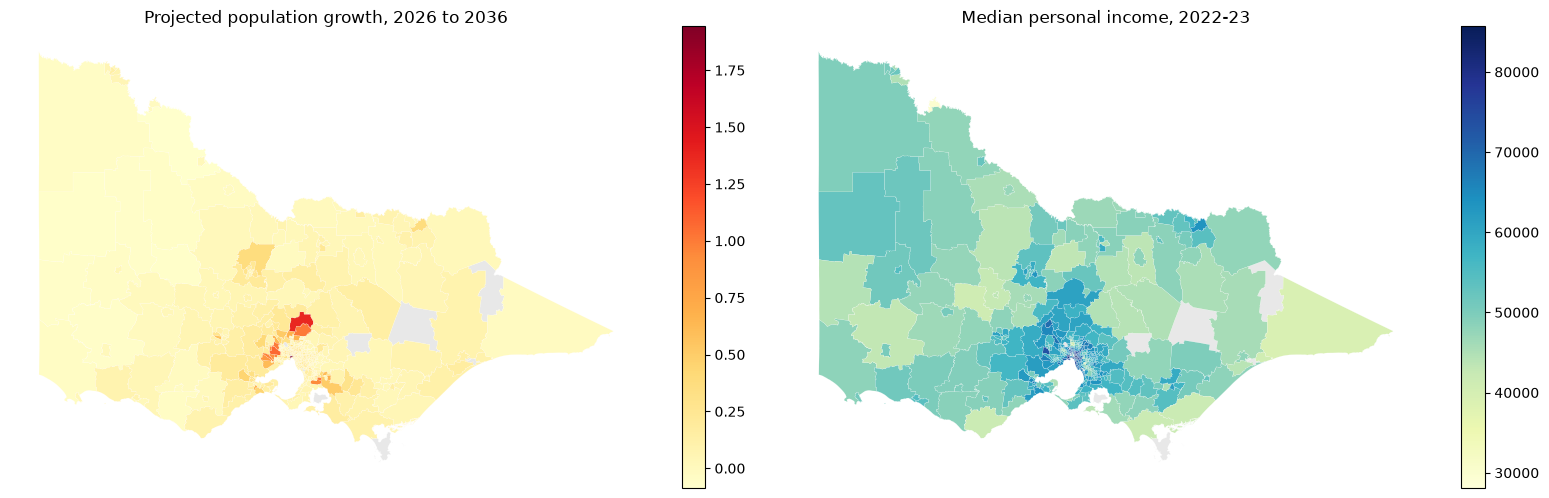

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

plot_data = sa2_features[sa2_features["is_modelling_ready"]]
grey = sa2_features[~sa2_features["is_modelling_ready"]]

for ax, col, title, cmap in [
    (axes[0], "population_growth_10y", "Projected population growth, 2026 to 2036", "YlOrRd"),
    (axes[1], "income_median", "Median personal income, 2022-23", "YlGnBu"),
]:
    grey.plot(ax=ax, color="#e8e8e8", edgecolor="white", linewidth=0.1)
    plot_data.plot(
        column=col, ax=ax, cmap=cmap, legend=True,
        edgecolor="white", linewidth=0.1,
        legend_kwds={"shrink": 0.6},
    )
    ax.set_title(title)
    ax.set_axis_off()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "plots" / "sa2_growth_and_income.png", dpi=150)
plt.show()

In [25]:
SCHOOLS_FILE = LANDING_DIR / "schools" / "dv378_DataVic-SchoolLocations-2024.csv"
assert SCHOOLS_FILE.exists(), f"Schools file not found at {SCHOOLS_FILE}"

# The file is not UTF-8. School names such as St Mary's College use the
# Windows curly apostrophe, which raises a UnicodeDecodeError under the
# default encoding.
schools_raw = pd.read_csv(SCHOOLS_FILE, encoding="cp1252")
print(f"Raw rows: {len(schools_raw)}")

# X is longitude and Y is latitude, following the usual GIS convention.
# Renaming them removes any chance of transposing the pair later.
schools = schools_raw.rename(columns={"X": "longitude", "Y": "latitude"})

missing_coords = schools["longitude"].isna() | schools["latitude"].isna()
print(f"Rows without coordinates: {missing_coords.sum()}")
if missing_coords.any():
    print(schools[missing_coords][["School_Name", "Address_Town"]].to_string(index=False))

schools = schools[~missing_coords].copy()

# Sanity bounds for Victoria. Anything outside these is a coordinate error.
assert schools["longitude"].between(140.9, 150.1).all(), "Longitude outside Victoria"
assert schools["latitude"].between(-39.2, -33.9).all(), "Latitude outside Victoria"

print(f"\nSchools with valid coordinates: {len(schools)}")
print(f"\nEducation sector\n{schools['Education_Sector'].value_counts().to_string()}")
print(f"\nSchool type\n{schools['School_Type'].value_counts().to_string()}")

Raw rows: 2294
Rows without coordinates: 1
                School_Name Address_Town
St Ignatius College Geelong     DRYSDALE

Schools with valid coordinates: 2293

Education sector
Education_Sector
Government     1570
Catholic        494
Independent     229

School type
School_Type
Primary      1570
Secondary     356
Pri/Sec       249
Special       114
Language        4


In [26]:
# Build point geometry. The source coordinates are plain WGS84 degrees, so
# they are created as EPSG 4326 and then reprojected onto the boundary file's
# CRS. Joining two layers with different CRSs either raises or, worse in some
# versions, silently misplaces every point.
schools_gdf = gpd.GeoDataFrame(
    schools,
    geometry=gpd.points_from_xy(schools["longitude"], schools["latitude"]),
    crs="EPSG:4326",
).to_crs(sa2_vic.crs)

assert schools_gdf.crs == sa2_vic.crs, "CRS mismatch before spatial join"

# Point in polygon. Suburb or town names are never used for this, because a
# town can span several SA2s and an SA2 can contain several towns, so name
# matching yields confident but wrong assignments.
schools_sa2 = gpd.sjoin(
    schools_gdf,
    sa2_vic[["SA2_CODE21", "SA2_NAME21", "geometry"]],
    how="left",
    predicate="within",
).rename(columns={"SA2_CODE21": "sa2_code_2021", "SA2_NAME21": "sa2_name_2021"})

# A left join cannot lose rows, but it can duplicate them if the boundaries
# overlap. ABS boundaries are exhaustive and non overlapping, so the count
# must be unchanged.
assert len(schools_sa2) == len(schools_gdf), \
    f"Spatial join changed row count from {len(schools_gdf)} to {len(schools_sa2)}"

unmatched = schools_sa2["sa2_code_2021"].isna()
print(f"Schools matched to an SA2: {(~unmatched).sum()}")
print(f"Schools outside all SA2 boundaries: {unmatched.sum()}")
if unmatched.any():
    print(
        schools_sa2[unmatched][
            ["School_Name", "Address_Town", "longitude", "latitude"]
        ].to_string(index=False)
    )

Schools matched to an SA2: 2293
Schools outside all SA2 boundaries: 0


In [27]:
# Two outputs are needed from the schools data. The SA2 level counts feed the
# area profile, and the individual points feed the property level proximity
# features once real coordinates arrive.

schools_clean = schools_sa2[[
    "School_No", "School_Name", "Education_Sector", "School_Type",
    "Address_Town", "LGA_Name", "longitude", "latitude",
    "sa2_code_2021", "sa2_name_2021",
]].copy()

school_points_path = RAW_DIR / "vic_school_points.parquet"
schools_clean.to_parquet(school_points_path, index=False)
print(f"Wrote {len(schools_clean)} school points to {school_points_path.name}")

# SA2 level counts. Primary and secondary are separated because families with
# school age children weigh them differently, and Pri/Sec campuses count
# towards both.
schools_clean["has_primary"] = schools_clean["School_Type"].isin(["Primary", "Pri/Sec"])
schools_clean["has_secondary"] = schools_clean["School_Type"].isin(["Secondary", "Pri/Sec"])
schools_clean["is_government"] = schools_clean["Education_Sector"] == "Government"

school_counts = (
    schools_clean
    .groupby("sa2_code_2021")
    .agg(
        n_schools=("School_No", "size"),
        n_primary_schools=("has_primary", "sum"),
        n_secondary_schools=("has_secondary", "sum"),
        n_government_schools=("is_government", "sum"),
    )
    .reset_index()
)

print(f"\nSA2s with at least one school: {len(school_counts)} of 524")
print(school_counts[["n_schools", "n_primary_schools", "n_secondary_schools"]].describe().round(2))

Wrote 2293 school points to vic_school_points.parquet

SA2s with at least one school: 503 of 524
       n_schools  n_primary_schools  n_secondary_schools
count     503.00             503.00               503.00
mean        4.56               3.62                 1.20
std         2.47               2.05                 1.12
min         1.00               0.00                 0.00
25%         3.00               2.00                 0.00
50%         4.00               3.00                 1.00
75%         6.00               5.00                 2.00
max        14.00              12.00                 7.00


In [28]:
PTV_ZIP = LANDING_DIR / "ptv" / "gtfs.zip"
assert PTV_ZIP.exists(), f"GTFS archive not found at {PTV_ZIP}"


def read_gtfs_file(branch, filename):
    """
    Read one GTFS text file from an operational branch without unpacking.

    The PTV archive nests one google_transit.zip per branch inside the outer
    gtfs.zip. The inner archive is opened from the byte stream of the outer
    one, since extracting the whole archive would write over three hundred
    megabytes of timetable data that this project never reads.

    The path prefix is located by search rather than hard coded. Entries sit
    at the archive root as "1/google_transit.zip", but unpacking the archive
    adds a "gtfs" folder on top, so a path matching the unpacked layout fails
    against the archive itself.
    """
    with zipfile.ZipFile(PTV_ZIP) as outer:
        matches = [
            n for n in outer.namelist()
            if n.endswith("google_transit.zip")
            and n.split("/")[-2] == str(branch)
        ]
        if len(matches) != 1:
            raise FileNotFoundError(
                f"Expected one inner archive for branch {branch}, found {matches}"
            )
        inner_bytes = outer.read(matches[0])
    with zipfile.ZipFile(io.BytesIO(inner_bytes)) as inner:
        return pd.read_csv(inner.open(filename))


# Branch identification. agency.txt names every branch "Transport Victoria",
# so the mode was determined from route_type in routes.txt instead:
#
#   Branch 1   Rail          111 stations   regional, V/Line
#   Branch 2   type 400      226 stations   suburban, Metro
#   Branch 10  type 102       10 stations   long distance interstate
#   Branch 3   Tram            0 stations
#   Branch 4,5,6,11  Bus       0 stations
#
# Only the rail branches carry location_type 1 records, since trams and buses
# have no multi platform structure requiring in station navigation. Melbourne
# tram stops sit every few hundred metres, so including them would make a
# nearest stop distance feature almost constant across the inner suburbs.
RAIL_BRANCHES = {"1": "regional", "2": "metropolitan"}

print(f"Reading rail branches {list(RAIL_BRANCHES)} from {PTV_ZIP.name}")

Reading rail branches ['1', '2'] from gtfs.zip


In [29]:
station_frames = []
for branch, network in RAIL_BRANCHES.items():
    stops = read_gtfs_file(branch, "stops.txt")

    # location_type 1 marks a station. The remaining records are individual
    # platforms, entrances and bus replacement points, so a station such as
    # Flinders Street appears many times without this filter.
    stations = stops[stops["location_type"] == 1].copy()
    stations["network"] = network
    station_frames.append(
        stations[["stop_id", "stop_name", "stop_lat", "stop_lon", "network"]]
    )
    print(f"Branch {branch} ({network}): {len(stations)} stations from {len(stops)} records")

stations = pd.concat(station_frames, ignore_index=True)
stations = stations.rename(columns={"stop_lat": "latitude", "stop_lon": "longitude"})
print(f"\nTotal station records: {len(stations)}")

Branch 1 (regional): 111 stations from 627 records
Branch 2 (metropolitan): 226 stations from 2859 records

Total station records: 337


In [30]:
# The 34 duplicated names share an identical stop_id and identical
# coordinates, since PTV publishes the same station record in both branch
# archives. Deduplicating on stop_id is therefore lossless. A flag records
# which stations serve both networks, because a station with V/Line services
# offers a materially different level of connectivity.
both_networks = set(
    stations.loc[stations["stop_id"].duplicated(keep=False), "stop_id"]
)

stations_unique = (
    stations
    .drop_duplicates(subset="stop_id", keep="first")
    .copy()
    .reset_index(drop=True)
)
stations_unique["serves_both_networks"] = (
    stations_unique["stop_id"].isin(both_networks)
)

assert stations_unique["stop_id"].is_unique, "stop_id must be unique after dedup"
print(f"Unique stations: {len(stations_unique)}")
print(f"Serving both networks: {stations_unique['serves_both_networks'].sum()}")

# Confirm the deduplication lost no location information
coord_check = stations.groupby("stop_id")[["latitude", "longitude"]].nunique()
assert (coord_check <= 1).all().all(), \
    "A stop_id carries conflicting coordinates across branches"
print("Coordinate consistency check passed")

assert stations_unique["latitude"].between(-39.2, -33.9).all(), "Latitude outside Victoria"
assert stations_unique["longitude"].between(140.9, 150.1).all(), "Longitude outside Victoria"

Unique stations: 320
Serving both networks: 17
Coordinate consistency check passed


In [31]:
stations_gdf = gpd.GeoDataFrame(
    stations_unique,
    geometry=gpd.points_from_xy(
        stations_unique["longitude"], stations_unique["latitude"]
    ),
    crs="EPSG:4326",
).to_crs(sa2_vic.crs)

stations_sa2 = gpd.sjoin(
    stations_gdf,
    sa2_vic[["SA2_CODE21", "SA2_NAME21", "geometry"]],
    how="left",
    predicate="within",
).rename(columns={"SA2_CODE21": "sa2_code_2021", "SA2_NAME21": "sa2_name_2021"})

assert len(stations_sa2) == len(stations_gdf), "Spatial join changed row count"

unmatched = stations_sa2["sa2_code_2021"].isna()
print(f"Stations matched to an SA2: {(~unmatched).sum()}")
print(f"Stations outside all SA2 boundaries: {unmatched.sum()}")
if unmatched.any():
    print(stations_sa2[unmatched][["stop_name", "longitude", "latitude"]].to_string(index=False))

station_path = RAW_DIR / "vic_train_stations.parquet"
stations_sa2.drop(columns=["geometry", "index_right"]).to_parquet(station_path, index=False)
print(f"\nWrote {len(stations_sa2)} stations to {station_path.name}")

Stations matched to an SA2: 319
Stations outside all SA2 boundaries: 1
             stop_name  longitude   latitude
Albury Railway Station 146.924381 -36.085046

Wrote 320 stations to vic_train_stations.parquet


In [32]:
# Albury station sits in New South Wales, a few kilometres north of the state
# border, and is the terminus of the V/Line Albury line. It correctly returns
# no Victorian SA2. It is retained rather than dropped because for properties
# near Wodonga it may genuinely be the nearest station, and removing it would
# inflate their distance to rail.
stations_final = stations_sa2.drop(columns=["geometry", "index_right"]).copy()
stations_final["in_victoria"] = stations_final["sa2_code_2021"].notna()

print(f"Stations inside Victoria: {stations_final['in_victoria'].sum()}")
print(f"Stations outside Victoria, retained for proximity: {(~stations_final['in_victoria']).sum()}")

station_path = RAW_DIR / "vic_train_stations.parquet"
stations_final.to_parquet(station_path, index=False)

check = pd.read_parquet(station_path)
assert len(check) == 320, f"Round trip failed, got {len(check)} rows"
assert check["stop_id"].is_unique, "stop_id must remain unique"
print(f"\nWrote {len(check)} stations to {station_path.name}")

# SA2 level station counts
station_counts = (
    stations_final[stations_final["in_victoria"]]
    .groupby("sa2_code_2021")
    .agg(
        n_stations=("stop_id", "size"),
        n_stations_both_networks=("serves_both_networks", "sum"),
    )
    .reset_index()
)
print(f"\nSA2s with at least one station: {len(station_counts)} of 524")
print(station_counts["n_stations"].describe().round(2))

Stations inside Victoria: 319
Stations outside Victoria, retained for proximity: 1

Wrote 320 stations to vic_train_stations.parquet

SA2s with at least one station: 214 of 524
count    214.00
mean       1.49
std        0.78
min        1.00
25%        1.00
50%        1.00
75%        2.00
max        5.00
Name: n_stations, dtype: float64


In [33]:
# School and station counts are joined onto the SA2 profile. Both are area
# level summaries with a known weakness: an SA2 with no station may still sit
# a few hundred metres from one across its boundary. The property level
# distance features computed later are the primary measure of access, and
# these counts serve as a coarse area characteristic only.
sa2_features_v2 = (
    sa2_features
    .merge(school_counts, on="sa2_code_2021", how="left")
    .merge(station_counts, on="sa2_code_2021", how="left")
)

count_cols = [
    "n_schools", "n_primary_schools", "n_secondary_schools",
    "n_government_schools", "n_stations", "n_stations_both_networks",
]
# A left join leaves nulls where an SA2 contains no school or station. Zero is
# the correct value here, unlike the demographic columns where a null means
# the data was unavailable rather than the quantity being zero.
sa2_features_v2[count_cols] = sa2_features_v2[count_cols].fillna(0).astype(int)

assert len(sa2_features_v2) == 524, f"Merge changed row count to {len(sa2_features_v2)}"
assert isinstance(sa2_features_v2, gpd.GeoDataFrame), "Geometry lost in merge"

print(f"SA2s with no school: {(sa2_features_v2['n_schools'] == 0).sum()}")
print(f"SA2s with no station: {(sa2_features_v2['n_stations'] == 0).sum()}")
print(f"Combined table: {len(sa2_features_v2)} rows, {len(sa2_features_v2.columns)} columns")

sa2_features_v2.to_file(CURATED_DIR / "sa2_features.gpkg", driver="GPKG", engine="pyogrio")
sa2_features_v2.drop(columns=["geometry"]).to_parquet(
    CURATED_DIR / "sa2_features.parquet", index=False
)

final = pd.read_parquet(CURATED_DIR / "sa2_features.parquet")
assert len(final) == 524, "Round trip row count changed"
assert final["sa2_code_2021"].str.len().eq(9).all(), "SA2 code padding lost"
assert final[count_cols].notna().all().all(), "Counts must never be null"
print(f"\nRewrote sa2_features with {len(final.columns)} columns")

SA2s with no school: 21
SA2s with no station: 310
Combined table: 524 rows, 39 columns

Rewrote sa2_features with 38 columns
